In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from datasets import load_dataset

In [7]:
# Load the dataset
dataset = load_dataset("lavita/ChatDoctor-HealthCareMagic-100k", split="train")

In [8]:
# shuffle and grab 10K rows for our project
sampled_dataset = dataset.shuffle(seed=42).select(range(10000))
df = pd.DataFrame(sampled_dataset)

As we can see, the Doctor's answers (green) are much longer and more detailed than the patient's questions (blue). Therefore, I set my model's max_seq_length to 512 to ensure the AI has enough room to generate a full medical diagnosis.

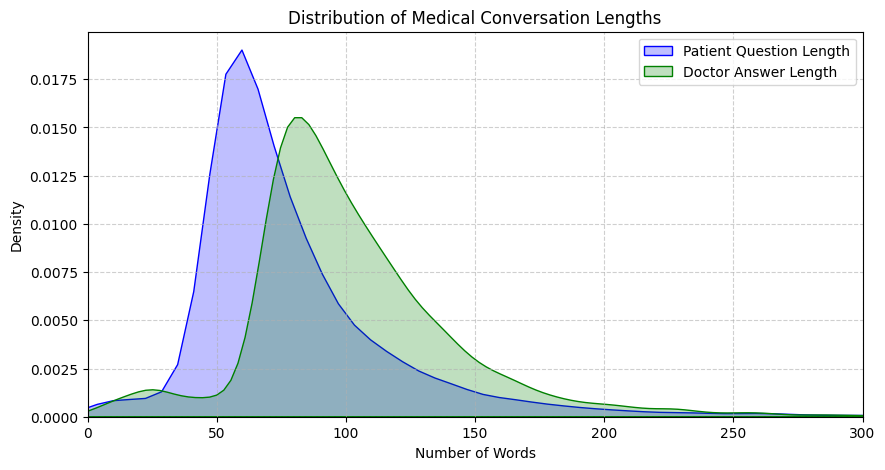

In [9]:
# We calculate how many words the patient types vs the doctor
df['patient_word_count'] = df['input'].apply(lambda x: len(str(x).split()))
df['doctor_word_count'] = df['output'].apply(lambda x: len(str(x).split()))


plt.figure(figsize=(10, 5))
sns.kdeplot(df['patient_word_count'], color='blue', fill=True, label='Patient Question Length')
sns.kdeplot(df['doctor_word_count'], color='green', fill=True, label='Doctor Answer Length')
plt.title('Distribution of Medical Conversation Lengths')
plt.xlabel('Number of Words')
plt.ylabel('Density')
plt.xlim(0, 300)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig("medical_lengths.png")
plt.show()

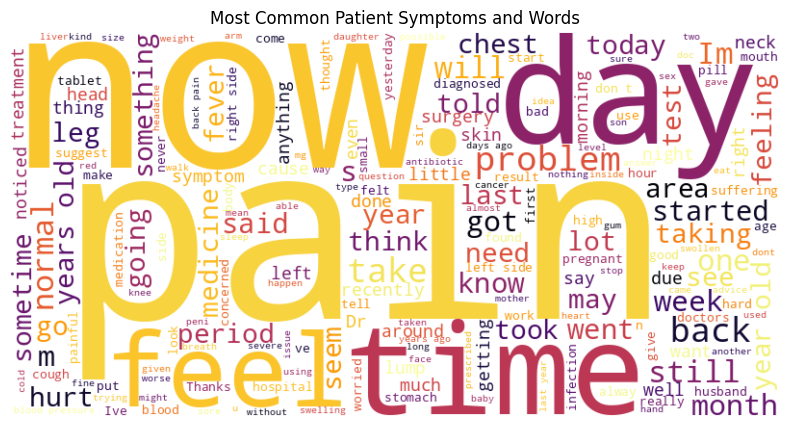

In [10]:
# Let's see what patients are complaining about!
stopwords = set(STOPWORDS)
stopwords.update(["hi", "hello", "doctor", "please", "help", "thank", "you"])

patient_text = " ".join(text for text in df['input'])

wordcloud = WordCloud(width=800, height=400, background_color="white",
                      stopwords=stopwords, colormap="inferno").generate(patient_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Common Patient Symptoms and Words")
plt.savefig("symptoms_wordcloud.png")
plt.show()